Загрузите файл online_retail_II.xlsx


Saving online_retail_II.xlsx to online_retail_II (1).xlsx
Все библиотеки успешно загружены.
Исходный размер данных: (525461, 8)
После очистки: (48541, 8)
Уникальных покупателей: 3684
Уникальных товаров: 50
Временной интервал: 2009-12-01 07:45:00 – 2010-12-09 20:01:00
Клиентов с минимум 2 транзакциями: 2325
Средняя длина цепочки покупок: 5.3
Медианная длина: 3
Максимальная длина: 146

Функция sequence_mining_apriori готова.

Синтетические цепочки покупок:
  Клиент 1: {'B', 'A'} → {'C'} → {'A'}
  Клиент 2: {'A'} → {'C', 'B'} → {'A'}
  Клиент 3: {'B', 'A'} → {'C'}
  Клиент 4: {'B'} → {'C', 'A'}
  Длина 2: найдено 5 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 0 частых последовательностей

Частых последовательностей при min_support=50%: 9
  <{'A'} → {'C'} → {'A'}>  support=0.50 (n=2/4)
  <{'A'} → {'C'}>  support=0.75 (n=3/4)
  <{'B'} → {'C'}>  support=0.75 (n=3/4)
  <{'B'} → {'A'}>  support=0.75 (n=3/4)
  <{'C'} → {'A'}>  support=0.50 (n=2/4

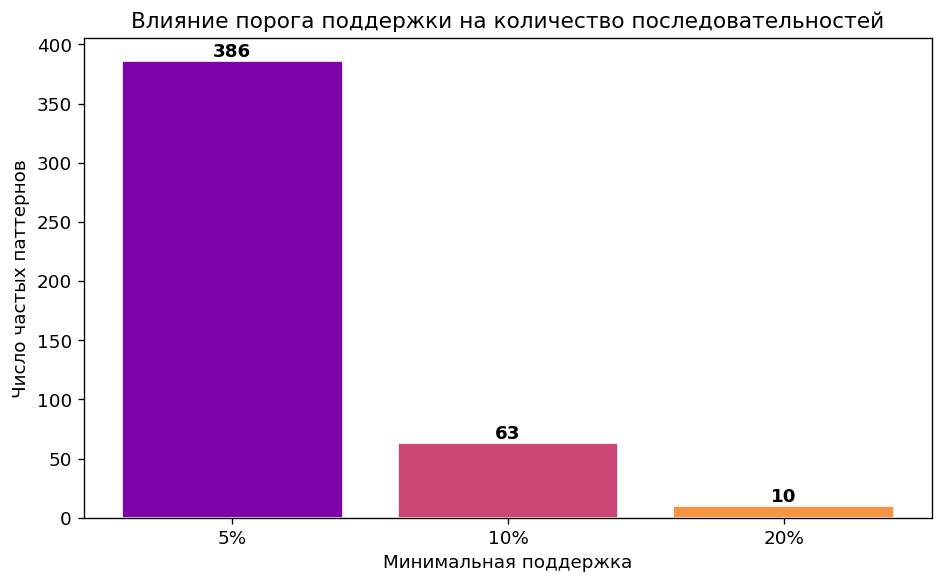


Интерпретация: чем выше порог, тем меньше обнаруживается паттернов.
При низком пороге алгоритм находит много редких шаблонов,
но время работы возрастает – проявляется проблема масштабируемости.

Всего транзакций для анализа правил: 12394

Топ-3 ассоциативных правила по Lift:
  1. {'RED HANGING HEART T-LIGHT HOLDER'} -> {'WHITE HANGING HEART T-LIGHT HOLDER'}  s=0.053  c=0.731  lift=3.25
  2. {'WHITE HANGING HEART T-LIGHT HOLDER'} -> {'RED HANGING HEART T-LIGHT HOLDER'}  s=0.053  c=0.237  lift=3.25

Проверка, являются ли эти правила частыми последовательностями вида <{A},{B}>:
  Правило 1: <{RED HANGING HEART T-LIGHT HOLDER},{WHITE HANGING HEART T-LIGHT HOLDER}> s=0.115, <{WHITE HANGING HEART T-LIGHT HOLDER},{RED HANGING HEART T-LIGHT HOLDER}> s=0.122
  Правило 2: <{WHITE HANGING HEART T-LIGHT HOLDER},{RED HANGING HEART T-LIGHT HOLDER}> s=0.122, <{RED HANGING HEART T-LIGHT HOLDER},{WHITE HANGING HEART T-LIGHT HOLDER}> s=0.115

Вывод: ассоциативные правила игнорируют порядок событий.
Тов

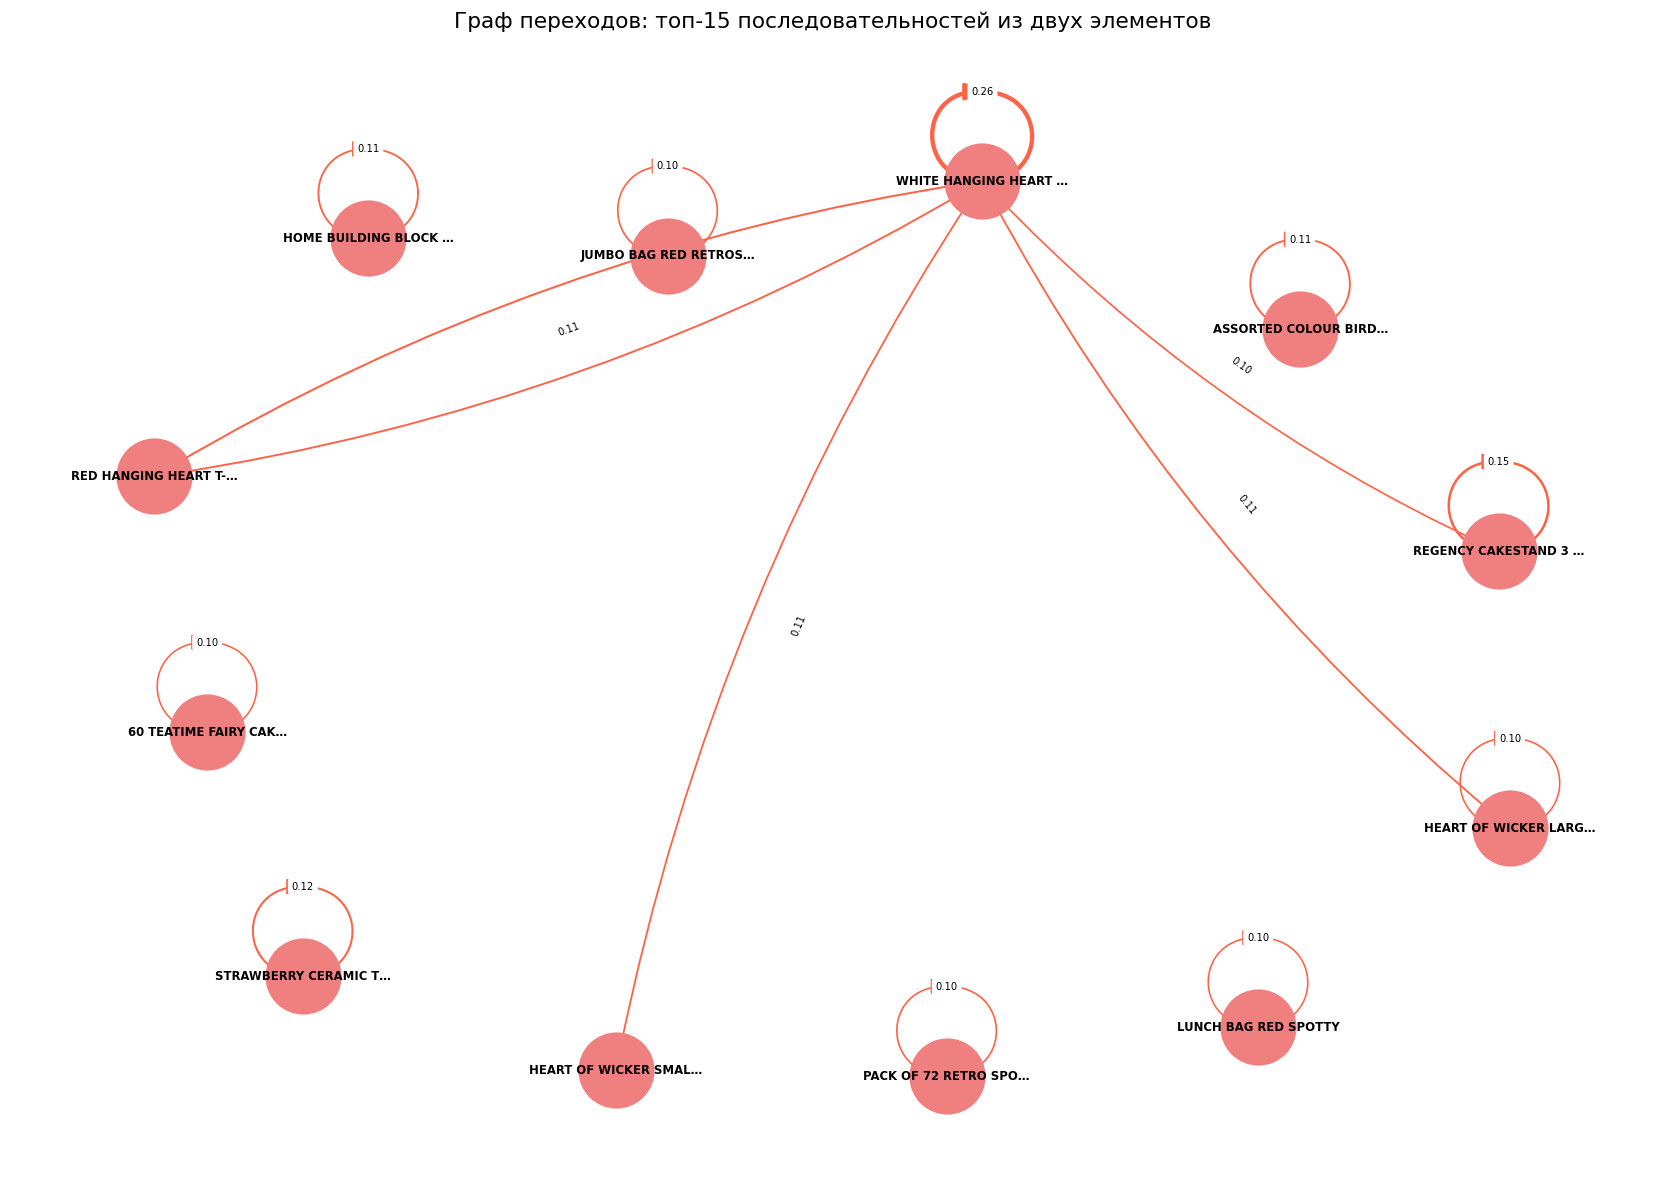


Самый частый переход: <{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'WHITE HANGING HEART T-LIGHT HOLDER'}> (support=0.259)
Бизнес-идея: после покупки первого товара клиенту можно предложить второй
через персонализированную рассылку или рекомендательный блок.

PrefixSpan (min_count=232, 10%)...
  Время PrefixSpan: 0.18 с, шаблонов: 83

AprioriAll (min_sup=10%)...
  Длина 2: найдено 12 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 0 частых последовательностей
  Время AprioriAll: 5.03 с, шаблонов: 63

Метод           Время (с)       Паттернов            Примечание
-----------------------------------------------------------------
AprioriAll      5.03            63                   наша реализация
PrefixSpan      0.18            83                   библиотечная версия

Примечание: PrefixSpan обычно быстрее на больших наборах данных,
так как не генерирует явных кандидатов и использует проекцию баз

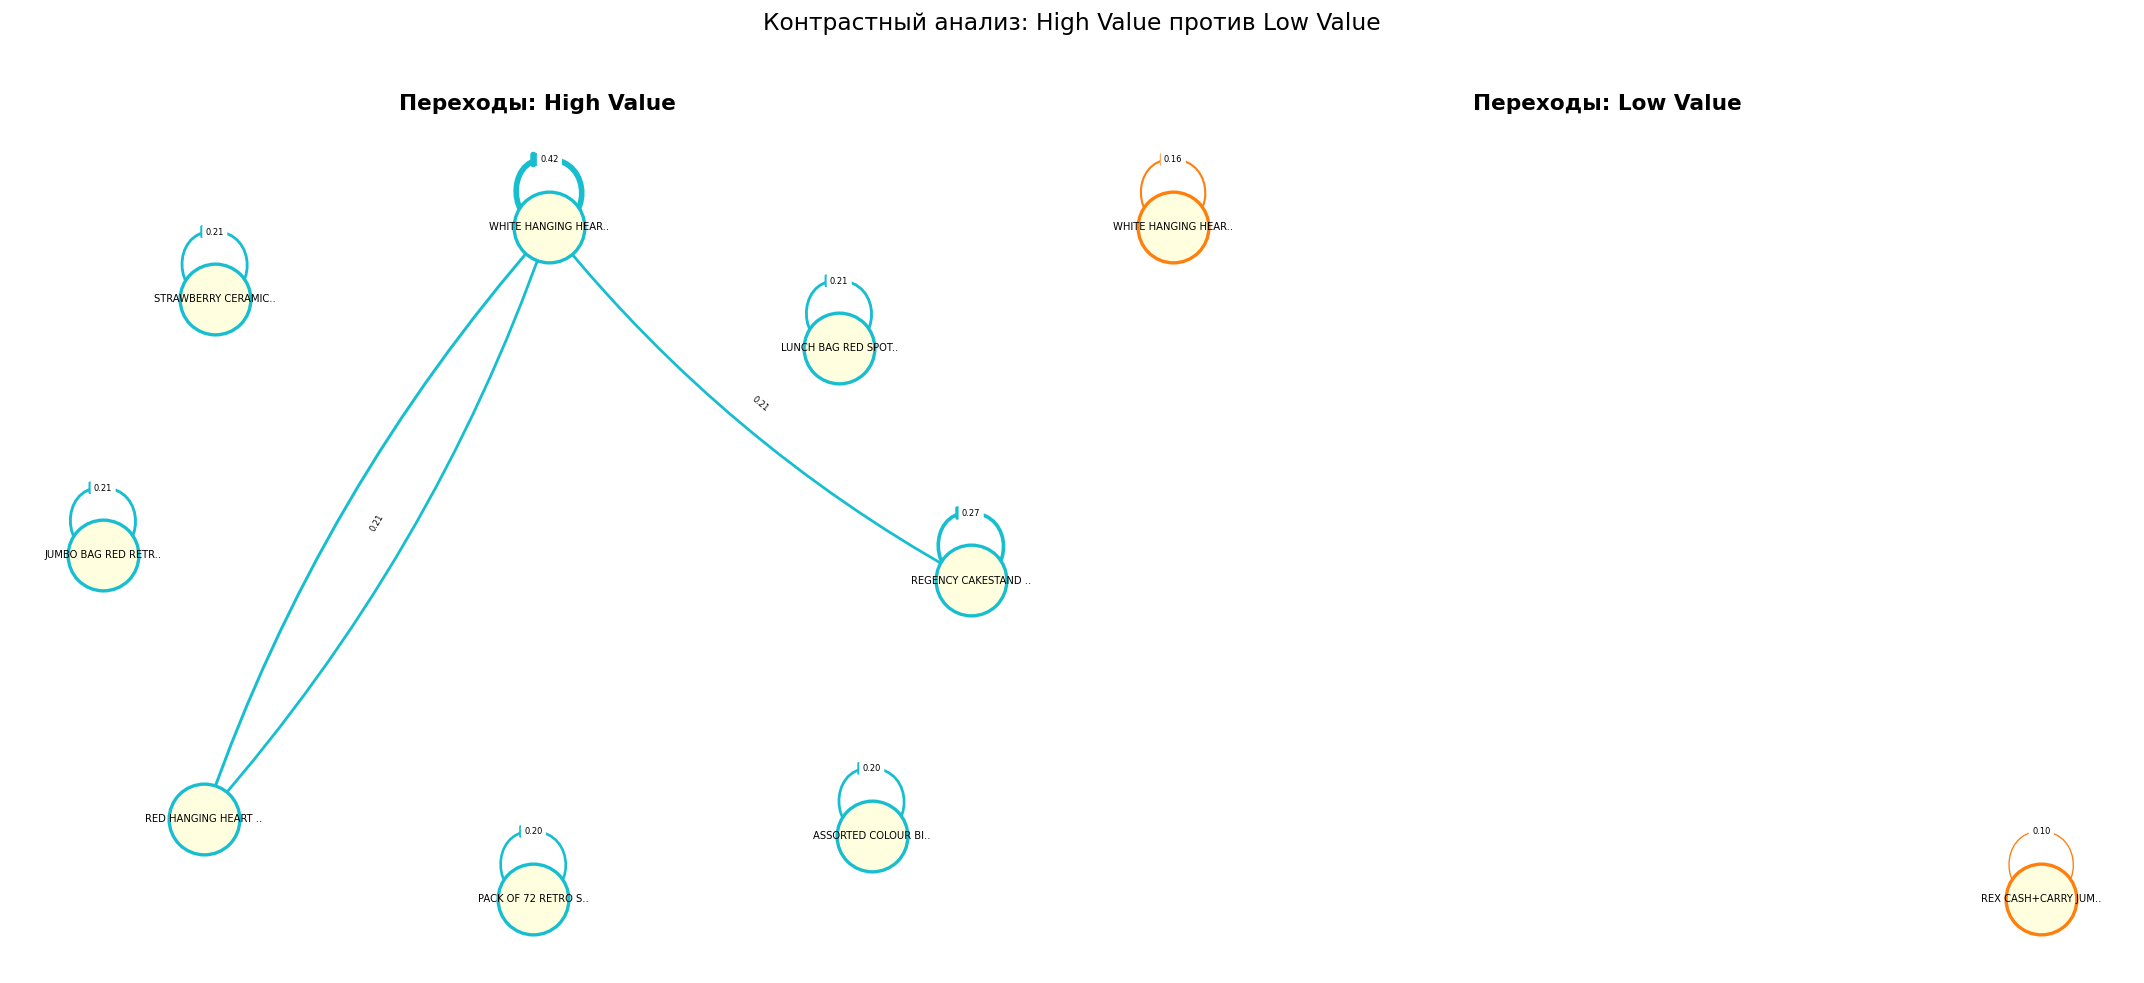

In [2]:
!pip install -q prefixspan openpyxl

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from google.colab import files
print("Загрузите файл online_retail_II.xlsx")
uploaded = files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time
from collections import defaultdict
from itertools import combinations
from prefixspan import PrefixSpan

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEED = 42
np.random.seed(SEED)
print("Все библиотеки успешно загружены.")

# Чтение файла
file_name = list(uploaded.keys())[0]
raw_data = pd.read_excel(file_name)
print(f"Исходный размер данных: {raw_data.shape}")
raw_data.head()

# Предварительная очистка
data = raw_data.copy()
data['Invoice'] = data['Invoice'].astype(str)
data = data[~data['Invoice'].str.startswith('C')]
data = data.dropna(subset=['Customer ID', 'Description'])
data = data[(data['Quantity'] > 0) & (data['Price'] > 0)]
data['Customer ID'] = data['Customer ID'].astype(int)

TOP = 50
top_products = data['Description'].value_counts().head(TOP).index.tolist()
data = data[data['Description'].isin(top_products)]

print(f"После очистки: {data.shape}")
print(f"Уникальных покупателей: {data['Customer ID'].nunique()}")
print(f"Уникальных товаров: {data['Description'].nunique()}")
print(f"Временной интервал: {data['InvoiceDate'].min()} – {data['InvoiceDate'].max()}")

# Функция построения клиентских последовательностей
def create_sequences(df):
    """
    Преобразует DataFrame в словарь:
    customer_id -> [(время транзакции, frozenset(товары)), ...]
    """
    sequences = {}
    for cust_id, group in df.groupby('Customer ID'):
        transactions = []
        for inv_id, inv_group in group.groupby('Invoice'):
            dt = inv_group['InvoiceDate'].min()
            products = frozenset(inv_group['Description'].unique())
            transactions.append((dt, products))
        # Сортируем по времени и оставляем тех, у кого >= 2 транзакций
        transactions.sort(key=lambda t: t[0])
        if len(transactions) >= 2:
            sequences[cust_id] = transactions
    return sequences

cust_sequences = create_sequences(data)
print(f"Клиентов с минимум 2 транзакциями: {len(cust_sequences)}")

# Статистики длин последовательностей
lens = [len(seq) for seq in cust_sequences.values()]
print(f"Средняя длина цепочки покупок: {np.mean(lens):.1f}")
print(f"Медианная длина: {np.median(lens):.0f}")
print(f"Максимальная длина: {max(lens)}")

# ---------- AprioriAll (реализация) ----------
def is_subseq(pattern, sequence):
    """
    Проверяет, содержится ли pattern как подпоследовательность в sequence.
    Оба параметра – списки frozenset.
    """
    idx = 0
    for itemset in sequence:
        if idx < len(pattern) and pattern[idx].issubset(itemset):
            idx += 1
    return idx == len(pattern)

def sequence_mining_apriori(seqs, min_sup, max_gap_days=None):
    """
    Обобщённый AprioriAll для поиска частых последовательностей.

    Параметры:
    seqs: dict {id: [(datetime, frozenset), ...]}
    min_sup: минимальная поддержка (доля)
    max_gap_days: максимальный допустимый разрыв в днях (None – без ограничения)

    Возвращает:
    dict {шаблон (tuple из frozenset): support}
    """
    total_customers = len(seqs)
    min_count = max(1, int(min_sup * total_customers))

    # Преобразуем в список списков (с учётом max_gap)
    db_sequences = {}
    for cid, txn_list in seqs.items():
        sorted_txn = sorted(txn_list, key=lambda x: x[0])
        if max_gap_days is not None:
            split_seqs = []
            current_chunk = [sorted_txn[0]]
            for i in range(1, len(sorted_txn)):
                gap = (sorted_txn[i][0] - current_chunk[-1][0]).days
                if gap <= max_gap_days:
                    current_chunk.append(sorted_txn[i])
                else:
                    items_only = [items for _, items in current_chunk]
                    if items_only:
                        split_seqs.append(items_only)
                    current_chunk = [sorted_txn[i]]
            items_only = [items for _, items in current_chunk]
            if items_only:
                split_seqs.append(items_only)
            db_sequences[cid] = split_seqs
        else:
            db_sequences[cid] = [[items for _, items in sorted_txn]]

    # 1. Частые 1-элементные множества
    item_counts = defaultdict(int)
    for sequences_list in db_sequences.values():
        seen = set()
        for seq in sequences_list:
            for itemset in seq:
                seen.update(itemset)
        for item in seen:
            item_counts[item] += 1

    freq_items = {item for item, cnt in item_counts.items() if cnt >= min_count}

    # Фильтрация последовательностей: оставляем только частые элементы
    filtered_db = {}
    for cid, sequences_list in db_sequences.items():
        new_seq_list = []
        for seq in sequences_list:
            filtered_seq = []
            for itemset in seq:
                filtered_set = itemset & freq_items
                if filtered_set:
                    filtered_seq.append(frozenset(filtered_set))
            if filtered_seq:
                new_seq_list.append(filtered_seq)
        filtered_db[cid] = new_seq_list

    all_freq_patterns = {}
    # Частые 1-последовательности
    for item in freq_items:
        pat = (frozenset([item]),)
        all_freq_patterns[pat] = item_counts[item] / total_customers

    # Итеративное наращивание длины
    current_candidates = list(all_freq_patterns.keys())
    unit_patterns = [p for p in all_freq_patterns if len(p) == 1]
    k = 2

    while current_candidates and k <= 5:
        next_candidates = set()
        for pat in current_candidates:
            for ext in unit_patterns:
                next_candidates.add(pat + ext)
        if not next_candidates:
            break

        new_freq = []
        for cand in next_candidates:
            cand_list = list(cand)
            cnt = 0
            for sequences_list in filtered_db.values():
                for seq in sequences_list:
                    if is_subseq(cand_list, seq):
                        cnt += 1
                        break
            if cnt >= min_count:
                all_freq_patterns[cand] = cnt / total_customers
                new_freq.append(cand)
        current_candidates = new_freq
        k += 1
        print(f"  Длина {k-1}: найдено {len(new_freq)} частых последовательностей")

    return all_freq_patterns

print("\nФункция sequence_mining_apriori готова.\n")

# Демонстрация на синтетическом примере
from datetime import datetime

example_seqs = {
    1: [(datetime(2024,1,1), frozenset(['A','B'])),
        (datetime(2024,1,5), frozenset(['C'])),
        (datetime(2024,1,10), frozenset(['A']))],
    2: [(datetime(2024,1,2), frozenset(['A'])),
        (datetime(2024,1,6), frozenset(['B','C'])),
        (datetime(2024,1,12), frozenset(['A']))],
    3: [(datetime(2024,1,1), frozenset(['A','B'])),
        (datetime(2024,1,8), frozenset(['C']))],
    4: [(datetime(2024,1,3), frozenset(['B'])),
        (datetime(2024,1,7), frozenset(['A','C']))]
}

print("Синтетические цепочки покупок:")
for cid, txn in example_seqs.items():
    path = " → ".join([str(set(it)) for _, it in txn])
    print(f"  Клиент {cid}: {path}")

result_example = sequence_mining_apriori(example_seqs, min_sup=0.5)

print(f"\nЧастых последовательностей при min_support=50%: {len(result_example)}")
for pattern, sup in sorted(result_example.items(), key=lambda x: (-len(x[0]), -x[1])):
    desc = " → ".join([str(set(s)) for s in pattern])
    print(f"  <{desc}>  support={sup:.2f} (n={int(sup*4)}/4)")

# Анализ влияния уровня поддержки
support_values = [0.05, 0.10, 0.20]
results_vs_support = {}

for sup in support_values:
    print(f"\nAprioriAll (min_sup={sup*100:.0f}%)...")
    start = time.time()
    patterns = sequence_mining_apriori(cust_sequences, min_sup=sup)
    elapsed = time.time() - start
    results_vs_support[sup] = patterns
    total_pat = len(patterns)
    by_len = defaultdict(int)
    for p in patterns:
        by_len[len(p)] += 1
    print(f"  Время выполнения: {elapsed:.1f} с, шаблонов: {total_pat}")
    for l in sorted(by_len):
        print(f"    Длина {l}: {by_len[l]}")

# График зависимости числа шаблонов от поддержки
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"{s*100:.0f}%" for s in support_values]
counts = [len(results_vs_support[s]) for s in support_values]
colors = sns.color_palette('plasma', len(counts))
bars = ax.bar(labels, counts, color=colors, edgecolor='white')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Минимальная поддержка')
ax.set_ylabel('Число частых паттернов')
ax.set_title('Влияние порога поддержки на количество последовательностей')
plt.tight_layout()
plt.show()

print("\nИнтерпретация: чем выше порог, тем меньше обнаруживается паттернов.")
print("При низком пороге алгоритм находит много редких шаблонов,")
print("но время работы возрастает – проявляется проблема масштабируемости.\n")

# Классические ассоциативные правила (товары, купленные совместно)
def classic_apriori(transactions, min_support):
    n = len(transactions)
    min_cnt = max(1, int(min_support * n))

    # Частые 1-элементные наборы
    item_cnt = defaultdict(int)
    for t in transactions:
        for item in t:
            item_cnt[frozenset([item])] += 1
    cur_freq = {it: c for it, c in item_cnt.items() if c >= min_cnt}
    all_freq_sets = {tuple(sorted(k)): v / n for k, v in cur_freq.items()}

    k = 2
    while cur_freq:
        prev = [tuple(sorted(s)) for s in cur_freq.keys()]
        candidates = set()
        for i in range(len(prev)):
            for j in range(i+1, len(prev)):
                union = frozenset(prev[i]) | frozenset(prev[j])
                if len(union) == k:
                    candidates.add(union)
        if not candidates:
            break
        cand_counts = defaultdict(int)
        for t in transactions:
            for c in candidates:
                if c.issubset(t):
                    cand_counts[c] += 1
        cur_freq = {c: cnt for c, cnt in cand_counts.items() if cnt >= min_cnt}
        for c, cnt in cur_freq.items():
            all_freq_sets[tuple(sorted(c))] = cnt / n
        k += 1
    return all_freq_sets

def make_rules(freq_sets, min_conf=0.1):
    rules = []
    for itemset_tup, supp in freq_sets.items():
        itemset = frozenset(itemset_tup)
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for ante_tup in combinations(sorted(itemset), i):
                ante = frozenset(ante_tup)
                cons = itemset - ante
                ante_k = tuple(sorted(ante))
                cons_k = tuple(sorted(cons))
                if ante_k not in freq_sets or cons_k not in freq_sets:
                    continue
                supp_ante = freq_sets[ante_k]
                conf = supp / supp_ante
                if conf < min_conf:
                    continue
                supp_cons = freq_sets[cons_k]
                lift = conf / supp_cons if supp_cons > 0 else float('inf')
                rules.append({
                    'antecedent': ante_tup,
                    'consequent': cons_k,
                    'support': supp,
                    'confidence': conf,
                    'lift': lift
                })
    return rules

# Строим транзакции "корзина" (без учёта порядка)
baskets = []
for _, txns in cust_sequences.items():
    for _, items in txns:
        clean = items & set(top_products)
        if clean:
            baskets.append(frozenset(clean))

print(f"Всего транзакций для анализа правил: {len(baskets)}")
itemsets_cl = classic_apriori(baskets, min_support=0.05)
rules_cl = make_rules(itemsets_cl, min_conf=0.1)

top3_lift = sorted(rules_cl, key=lambda r: r['lift'], reverse=True)[:3]
print("\nТоп-3 ассоциативных правила по Lift:")
for i, r in enumerate(top3_lift, 1):
    print(f"  {i}. {set(r['antecedent'])} -> {set(r['consequent'])}  "
          f"s={r['support']:.3f}  c={r['confidence']:.3f}  lift={r['lift']:.2f}")

# Сравнение с последовательностными паттернами
seq_patterns_005 = results_vs_support.get(0.05, {})
print("\nПроверка, являются ли эти правила частыми последовательностями вида <{A},{B}>:")
for i, r in enumerate(top3_lift, 1):
    for a in r['antecedent']:
        for c in r['consequent']:
            pat_ab = (frozenset([a]), frozenset([c]))
            pat_ba = (frozenset([c]), frozenset([a]))
            sup_ab = seq_patterns_005.get(pat_ab, 0)
            sup_ba = seq_patterns_005.get(pat_ba, 0)
            print(f"  Правило {i}: <{{{a}}},{{{c}}}> s={sup_ab:.3f}, "
                  f"<{{{c}}},{{{a}}}> s={sup_ba:.3f}")

print("\nВывод: ассоциативные правила игнорируют порядок событий.")
print("Товары, часто встречающиеся в одной корзине, не обязательно")
print("образуют временну́ю последовательность.\n")

# Влияние максимального допустимого разрыва (max_gap)
print("AprioriAll БЕЗ ограничения по времени (min_sup=10%)...")
t0 = time.time()
no_gap_res = sequence_mining_apriori(cust_sequences, min_sup=0.10)
t_no_gap = time.time() - t0
print(f"  Время: {t_no_gap:.1f} с, паттернов: {len(no_gap_res)}")

print("\nAprioriAll С ограничением max_gap=7 дней (min_sup=10%)...")
t0 = time.time()
gap7_res = sequence_mining_apriori(cust_sequences, min_sup=0.10, max_gap_days=7)
t_gap7 = time.time() - t0
print(f"  Время: {t_gap7:.1f} с, паттернов: {len(gap7_res)}")

only_no_gap = set(no_gap_res.keys()) - set(gap7_res.keys())
only_gap7   = set(gap7_res.keys()) - set(no_gap_res.keys())
common      = set(no_gap_res.keys()) & set(gap7_res.keys())

print(f"\nОбщих паттернов: {len(common)}")
print(f"Присутствуют только без gap: {len(only_no_gap)}")
print(f"Появляются только с gap=7: {len(only_gap7)}")

if only_no_gap:
    print("\nПример шаблона, исчезающего при max_gap=7:")
    ex = list(only_no_gap)[0]
    ex_str = " → ".join([str(set(s)) for s in ex])
    print(f"  <{ex_str}> (s={no_gap_res[ex]:.3f})")
    print("  Причина: транзакции разделены промежутком > 7 дней.")

if only_gap7:
    print("\nПример нового шаблона, появляющегося при max_gap=7:")
    ex = list(only_gap7)[0]
    ex_str = " → ".join([str(set(s)) for s in ex])
    print(f"  <{ex_str}> (s={gap7_res[ex]:.3f})")

# Граф переходов (2-последовательности)
pairs = {p: s for p, s in seq_patterns_005.items() if len(p) == 2}

if not pairs:
    print("Двухэлементных последовательностей не найдено, используем min_sup=0.05")
else:
    G = nx.DiGraph()
    # Берём 15 самых популярных переходов
    for pat, supp in sorted(pairs.items(), key=lambda x: -x[1])[:15]:
        src_items = list(pat[0])
        dst_items = list(pat[1])
        src = src_items[0] if len(src_items)==1 else str(set(pat[0]))
        dst = dst_items[0] if len(dst_items)==1 else str(set(pat[1]))
        src_lbl = src[:20] + '…' if len(str(src))>20 else str(src)
        dst_lbl = dst[:20] + '…' if len(str(dst))>20 else str(dst)
        G.add_edge(src_lbl, dst_lbl, weight=supp)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=2)
    w = [G[u][v]['weight'] * 10 for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=2000)
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
    nx.draw_networkx_edges(G, pos, width=w, edge_color='tomato',
                           arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.1')
    edge_annot = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_annot, font_size=6)
    plt.title('Граф переходов: топ-15 последовательностей из двух элементов')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    best_pat = max(pairs.items(), key=lambda x: x[1])
    best_str = " → ".join([str(set(s)) for s in best_pat[0]])
    print(f"\nСамый частый переход: <{best_str}> (support={best_pat[1]:.3f})")
    print("Бизнес-идея: после покупки первого товара клиенту можно предложить второй")
    print("через персонализированную рассылку или рекомендательный блок.\n")

# Сравнение AprioriAll и PrefixSpan
# Подготовка данных для PrefixSpan: список списков товаров
ps_data = []
for cid, txns in cust_sequences.items():
    order = []
    for _, items in txns:
        order.extend(sorted(items))
    ps_data.append(order)

min_sup_10 = 0.10
min_cnt_ps = max(1, int(min_sup_10 * len(ps_data)))

print(f"PrefixSpan (min_count={min_cnt_ps}, 10%)...")
start_ps = time.time()
ps_model = PrefixSpan(ps_data)
ps_model.minlen = 1
ps_model.maxlen = 5
freq_ps = ps_model.frequent(min_cnt_ps)
time_ps = time.time() - start_ps
print(f"  Время PrefixSpan: {time_ps:.2f} с, шаблонов: {len(freq_ps)}")

print(f"\nAprioriAll (min_sup=10%)...")
start_aa = time.time()
freq_aa = sequence_mining_apriori(cust_sequences, min_sup=min_sup_10)   # исправлено
time_aa = time.time() - start_aa
print(f"  Время AprioriAll: {time_aa:.2f} с, шаблонов: {len(freq_aa)}")

print("\n" + "="*65)
print(f"{'Метод':<15} {'Время (с)':<15} {'Паттернов':<20} {'Примечание'}")
print("-"*65)
print(f"{'AprioriAll':<15} {time_aa:<15.2f} {len(freq_aa):<20} {'наша реализация'}")
print(f"{'PrefixSpan':<15} {time_ps:<15.2f} {len(freq_ps):<20} {'библиотечная версия'}")
print("="*65)
print("\nПримечание: PrefixSpan обычно быстрее на больших наборах данных,")
print("так как не генерирует явных кандидатов и использует проекцию базы.\n")

# Разделение на Train / Test (80/20 по времени)
all_dates = []
for txns in cust_sequences.values():
    for dt, _ in txns:
        all_dates.append(dt)
all_dates.sort()
split_index = int(len(all_dates) * 0.8)
split_date = all_dates[split_index]
print(f"Дата разреза: {split_date}")

train_seq = {}
test_pairs = {}

for cid, txns in cust_sequences.items():
    train_part = [(dt, it) for dt, it in txns if dt <= split_date]
    test_part  = [(dt, it) for dt, it in txns if dt > split_date]
    if len(train_part) >= 2:
        train_seq[cid] = train_part
    if len(train_part) >= 1 and len(test_part) >= 1:
        last_train_basket = train_part[-1][1]
        first_test_basket = test_part[0][1]
        test_pairs[cid] = (last_train_basket, first_test_basket)

print(f"Обучающая выборка: {len(train_seq)} клиентов")
print(f"Тестовая выборка (с парами): {len(test_pairs)} клиентов")

print("\nОбучение AprioriAll на тренировочных данных...")
t0 = time.time()
train_patt = sequence_mining_apriori(train_seq, min_sup=0.05)
print(f"  Время обучения: {time.time()-t0:.1f} с, найдено паттернов: {len(train_patt)}")

pred_model = {}
for pat, sup in train_patt.items():
    if len(pat) == 2:
        for src in pat[0]:
            for dst in pat[1]:
                if src not in pred_model or sup > pred_model[src][1]:
                    pred_model[src] = (dst, sup)
print(f"Модель содержит правил: {len(pred_model)}")

item_pop = defaultdict(int)
for txns in train_seq.values():
    for _, items in txns:
        for it in items:
            item_pop[it] += 1
most_popular = max(item_pop, key=item_pop.get)
print(f"Базовый прогноз: всегда предлагать '{most_popular}'")

# Оценка точности
hit_seq = 0
hit_base = 0
total_test = 0

for cid, (last, next_basket) in test_pairs.items():
    total_test += 1
    # Предсказание по последовательностям
    best_candidate = None
    best_supp = -1
    for item in last:
        if item in pred_model:
            pred_item, conf = pred_model[item]
            if conf > best_supp:
                best_supp = conf
                best_candidate = pred_item
    if best_candidate and best_candidate in next_basket:
        hit_seq += 1
    # Базовое предсказание
    if most_popular in next_basket:
        hit_base += 1

acc_seq = hit_seq / max(total_test, 1)
acc_base = hit_base / max(total_test, 1)

print("\n" + "="*50)
print(f"{'Стратегия':<30} {'Точность@1'}")
print("-"*50)
print(f"{'Последовательная модель':<30} {acc_seq:.4f} ({hit_seq}/{total_test})")
print(f"{'Глобально популярный товар':<30} {acc_base:.4f} ({hit_base}/{total_test})")
print("="*50)

if acc_seq > acc_base:
    print(f"\nУчёт последовательностей повышает точность на {(acc_seq-acc_base)*100:.1f} п.п.")
else:
    print("\nБазовый метод не уступает. Возможно, популярный товар доминирует,")
    print("а последовательные паттерны слишком специфичны для обобщения.\n")

# Анализ High Value / Low Value клиентов
rev = data.groupby('Customer ID').apply(
    lambda g: (g['Quantity'] * g['Price']).sum()
).reset_index()
rev.columns = ['Customer ID', 'revenue']

thresh = rev['revenue'].quantile(0.75)
print(f"Порог High Value (75-й перцентиль): {thresh:.2f}")

high_ids = set(rev[rev['revenue'] >= thresh]['Customer ID'])
low_ids  = set(rev[rev['revenue'] < thresh]['Customer ID'])

high_seqs = {cid: seq for cid, seq in cust_sequences.items() if cid in high_ids}
low_seqs  = {cid: seq for cid, seq in cust_sequences.items() if cid in low_ids}
print(f"High Value: {len(high_seqs)} клиентов, Low Value: {len(low_seqs)} клиентов")

min_sup_contr = 0.10
print(f"\nЧастые последовательности High Value (min_sup={min_sup_contr*100:.0f}%)...")
hi_patterns = sequence_mining_apriori(high_seqs, min_sup=min_sup_contr)
print(f"  Найдено: {len(hi_patterns)}")

print(f"Частые последовательности Low Value (min_sup={min_sup_contr*100:.0f}%)...")
lo_patterns = sequence_mining_apriori(low_seqs, min_sup=min_sup_contr)
print(f"  Найдено: {len(lo_patterns)}")

# Контрастные паттерны: high_support - low_support
contrast_list = []
for pat, h_sup in hi_patterns.items():
    l_sup = lo_patterns.get(pat, 0)
    diff = h_sup - l_sup
    contrast_list.append((pat, h_sup, l_sup, diff))

contrast_list.sort(key=lambda x: -x[3])

print("\nТоп-5 характерных для High Value последовательностей:")
print(f"{'Шаблон':<50} {'HV sup':>8} {'LV sup':>8} {'Разница':>10}")
print("-"*80)
for pat, h_s, l_s, diff in contrast_list[:5]:
    pat_vis = " → ".join([str(set(s)) for s in pat])
    print(f"<{pat_vis[:47]:<47}> {h_s:>8.3f} {l_s:>8.3f} {diff:>+10.3f}")

print("\nГипотезы:")
for i, (pat, h_s, l_s, diff) in enumerate(contrast_list[:3], 1):
    elements = [list(s)[0] if len(s)==1 else str(set(s)) for s in pat]
    if len(elements) >= 2:
        print(f"  {i}. «Клиенты, покупающие сначала {elements[0]}, а затем {elements[1]},")
        print(f"     вероятнее окажутся высокодоходными» (контраст={diff:+.3f})")

# Визуализация графов High/Low Value
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
color_hv_node = '#2ca02c'   # зелёный оттенок
color_hv_edge = '#17becf'   # бирюзовый
color_lv_node = '#d62728'   # красноватый
color_lv_edge = '#ff7f0e'   # оранжевый

for ax, patterns, lbl, clr_node, clr_edge in [
    (axes[0], hi_patterns, 'High Value', color_hv_node, color_hv_edge),
    (axes[1], lo_patterns, 'Low Value',  color_lv_node, color_lv_edge)
]:
    pairs_hv = {p: s for p, s in patterns.items() if len(p) == 2}
    G_hv = nx.DiGraph()
    for pat, sup in sorted(pairs_hv.items(), key=lambda x: -x[1])[:10]:
        src = list(pat[0])[0] if len(pat[0])==1 else str(set(pat[0]))
        dst = list(pat[1])[0] if len(pat[1])==1 else str(set(pat[1]))
        s_l = src[:18]+'..' if len(str(src))>18 else str(src)
        d_l = dst[:18]+'..' if len(str(dst))>18 else str(dst)
        G_hv.add_edge(s_l, d_l, weight=sup)
    if G_hv.number_of_nodes() > 0:
        pos = nx.spring_layout(G_hv, seed=42, k=2)
        edge_widths = [G_hv[u][v]['weight'] * 8 for u, v in G_hv.edges()]
        nx.draw_networkx_nodes(G_hv, pos, node_color='lightyellow', node_size=1800,
                               edgecolors=clr_edge, linewidths=2, ax=ax)   # обводка цветом ребра
        nx.draw_networkx_labels(G_hv, pos, font_size=6, ax=ax)
        nx.draw_networkx_edges(G_hv, pos, width=edge_widths, edge_color=clr_edge,
                               arrows=True, arrowsize=15,
                               connectionstyle='arc3,rad=0.1', ax=ax)
        edge_lbls = {(u,v): f"{G_hv[u][v]['weight']:.2f}" for u,v in G_hv.edges()}
        nx.draw_networkx_edge_labels(G_hv, pos, edge_lbls, font_size=5, ax=ax)
    ax.set_title(f'Переходы: {lbl}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Контрастный анализ: High Value против Low Value', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()